In [106]:
import numpy as np
import matplotlib.pyplot as plt
# КОНСТАНТЫ 
fs = 32000 # ЧАСТОТА ДИСКРЕТИЗАЦИИ
dt = 1/fs # ШАГ ДИСКРЕТИЗАЦИИ
N = 1000 # КОЛИЧЕСТВО ТОЧЕК 
t = np.arange(N)*dt #ВЕКТОР ВРЕМЕНИ

# ПАРАМЕТРЫ АВП
M = 5 # КОЛИЧЕСТВО ДАТЧИКОВ
R = 1 # РАДИУС

# ПАРАМЕТРЫ СИГНАЛА 
wavelength = 20*R # ДЛИНА ВОЛНЫ (ИЗ УСЛОВИЯ МНОГО МЕНЬШЕ)
f = 1000 # ЦЕНТРАЛЬНАЯ ЧАСТОТА СИГНАЛА 
A = 2 # АМПЛИТУДА СИГНАЛА 
phi_0 = np.pi/4 # ФАЗА СИГНАЛА (ТО ЧТО ОЦЕНИВАЕМ)

# Параметры шумы
sigma_noise = 0.5

![АВП](visual1.png)

In [107]:
def get_gamma_array(M: int) -> np.ndarray:
    """Рассчет углов датчиков относительно оси x
    Функция принимает на вход число датчиков и возвращает 
    массив углов для каждого датчика"""
    
    return (2*np.pi/M)*np.arange(M)

def get_tau_array(M: int, 
                  R: float, 
                  phi_o: float, 
                  c: float = 343.26) -> np.ndarray:
    """Рассчёт задержек относительно каждого датчика"""
    
    return (R/c)*np.cos(phi_o - get_gamma_array(M))

In [108]:

def generate_signal(t: np.ndarray, 
                    f: float,
                    A: float = 1.0,) -> np.ndarray:
    """Считаем значение гармончиеского сигнала в каждый момент времени"""
    
    return  A*np.sin(t*(2*np.pi*f))
    

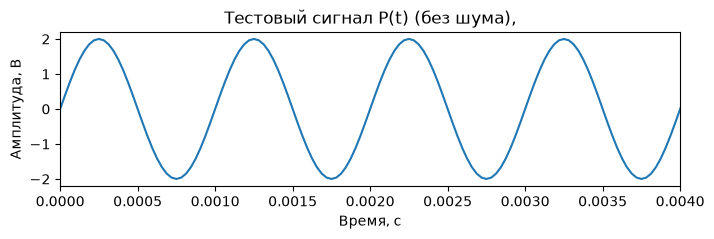

In [109]:
values_signal = generate_signal(t, f, A)
fig, ax = plt.subplots(1,1,figsize = (8,2))
ax.plot(t, values_signal)

ax.set_xlabel("Время, с")
ax.set_ylabel("Амплитуда, В")
ax.set_xlim(left = 0,  right = 0.004)
ax.set_title("Тестовый сигнал P(t) (без шума),")
plt.show()

In [110]:
def generate_noise(sigma):
    return np.random.normal(loc = 0, scale = sigma_noise, size = N)

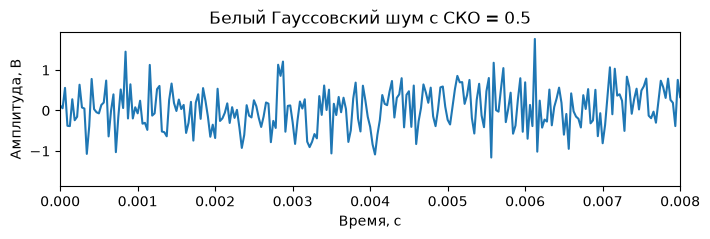

In [111]:
# ШУМ
noise = generate_noise(sigma_noise)
fig, ax = plt.subplots(1,1,figsize = (8,2))
ax.plot(t, noise)
ax.set_xlabel("Время, с")
ax.set_ylabel("Амплитуда, В")
ax.set_xlim(left = 0,  right = 0.008)
ax.set_title(rf"Белый Гауссовский шум с СКО = {sigma_noise}")
plt.show()

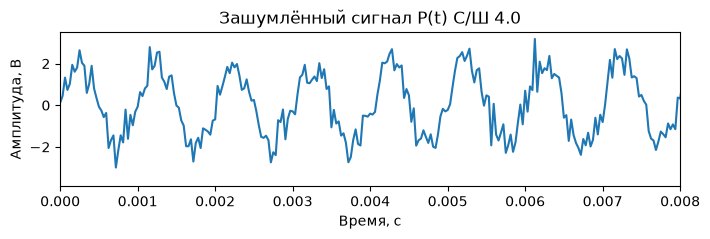

In [112]:
noise_signal = values_signal + noise
fig, ax = plt.subplots(1,1,figsize = (8,2))
ax.plot(t, noise_signal)
ax.set_xlabel("Время, с")
ax.set_ylabel("Амплитуда, В")
ax.set_xlim(left = 0,  right = 0.008)
ax.set_title(rf"Зашумлённый сигнал P(t) C/Ш {round(A/sigma_noise,2)}")
plt.show()

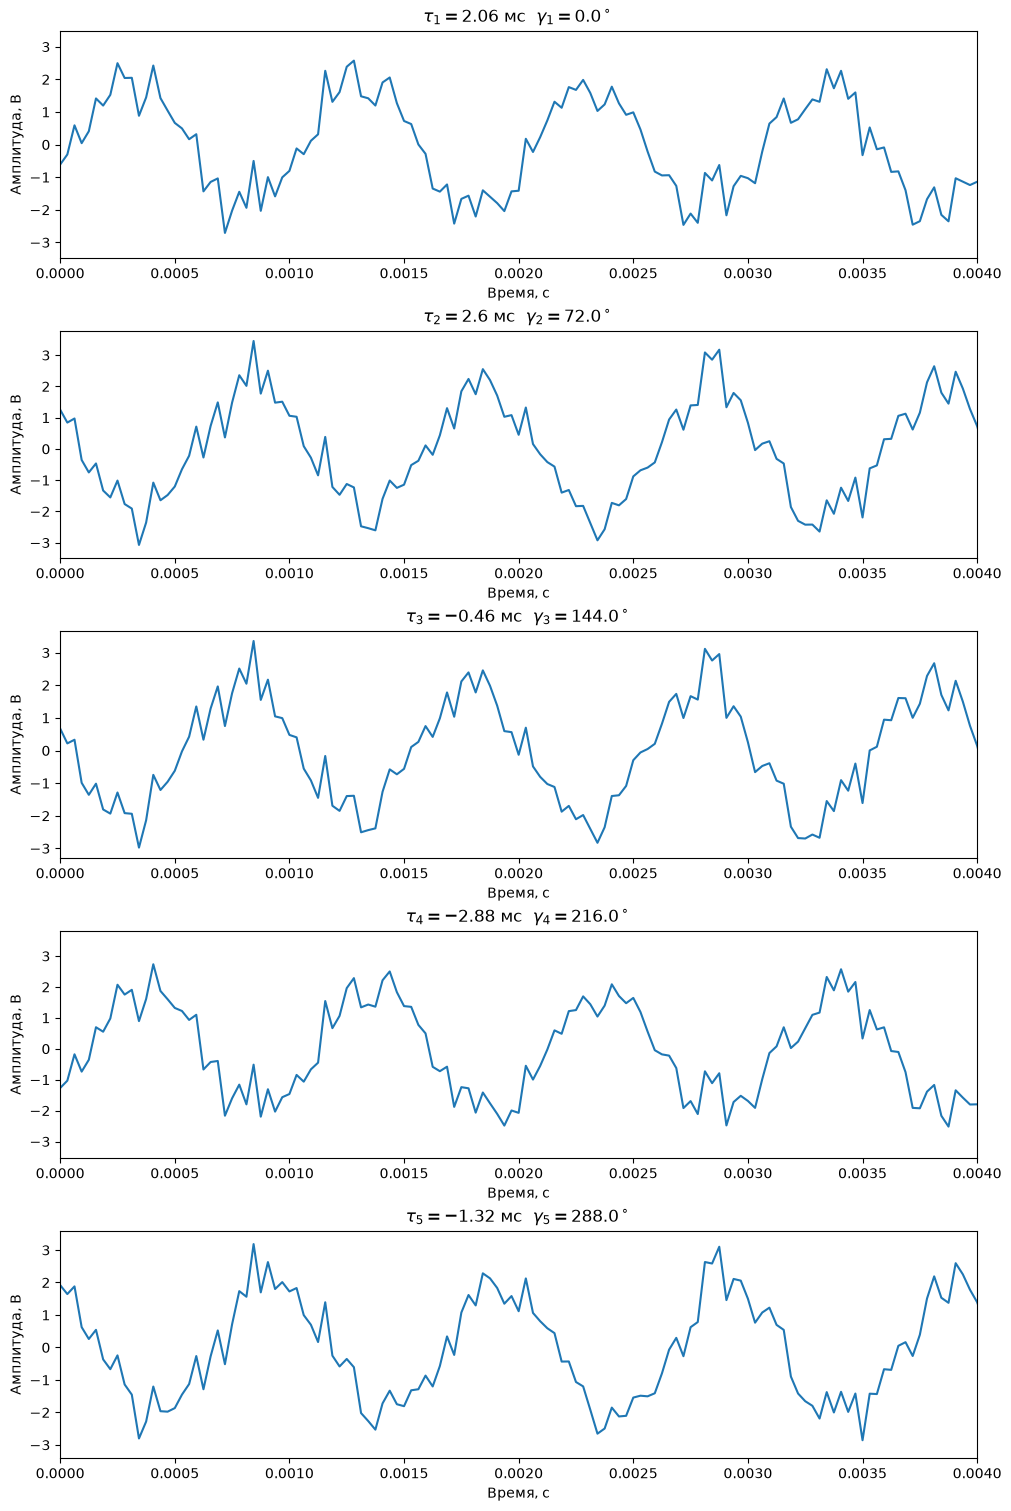

In [113]:
tau_array = get_tau_array(M, R, phi_0) # shape (M,)
gamma_array = get_gamma_array(M)
fig, axs = plt.subplots(M,1,figsize = (10,3*M),constrained_layout = True)

for idx, (tau, gamma) in enumerate(zip(tau_array, gamma_array)):
    
    signal = generate_signal(t - tau, f, A) + noise
    axs[idx].plot(t, signal)
    axs[idx].set_xlabel("Время, с")
    axs[idx].set_ylabel("Амплитуда, В")
    axs[idx].set_xlim(left = 0,  right = 0.004)
    axs[idx].set_title(rf"$\tau_{idx+1} = {round(tau*1000,2)} $ мс  $\gamma_{idx+1} = {round((gamma*180)/np.pi,2)}^\circ$")
    

In [ ]:


def generate_channel_matrix(
                      t: np.ndarray, 
                      f: float,
                      phi_0: float,
                      tau_array: np.ndarray,
                      M: int,
                      N: int,
                      noise_level: float = sigma_noise,
                      A: float = 1.0) -> np.ndarray:
    """Функция возращает матрицу 3M x N """
    channel_matrix = np.zeros((3*M, N)) # Создаём нулевую матрицу размера M x N
    for idx, tau in enumerate(tau_array):
        p_t = generate_signal(t - tau, f, A)

        y0 = p_t + generate_noise(noise_level\) # size (1 x N)
        y1 = p_t*np.cos(phi_0) + generate_noise(noise_level\)
        y2 = p_t*np.sin(phi_0) + generate_noise(noise_level\)
        sensor_matrix = np.vstack((y0, y1, y2)) 
        channel_matrix[idx*3:idx*3+3] = sensor_matrix
        
    return channel_matrix

In [115]:
def generate_covariation_matrix(matrix: np.ndarray,
                                N: int) -> np.ndarray:
    return (matrix @ matrix.T) / N


In [ ]:

channel_matrix = generate_channel_matrix(t, f, phi_0, tau_array, M,N) # (3M x N)
channel_matrix.shape

TypeError: generate_channel_matrix() missing 1 required positional argument: 'sigma_noise'

In [ ]:
W = generate_covariation_matrix(channel_matrix, N) # 3M x 3M
W.shape

(15, 15)